# Model Setup, Performance Testing & Remodelling

## Project Context
This notebook is the modelling hub for the Telco Customer Churn project. It covers the full modelling lifecycle in three phases:

**Phase 1 — Baseline Model Setup (Sections 1–7)**
Train and evaluate Logistic Regression, Random Forest, and XGBoost on both data pathways (Feature Selection vs. PCA) to establish baseline performance and select the best pathway.

**Phase 2 — Performance & Testing (Sections 8–10)**
Validate baseline results through cross-validation, optimise the decision threshold for the Precision/Recall trade-off, and visualise Precision-Recall curves.

**Phase 3 — Remodelling (Sections 11–13)**
Tune hyperparameters for all three models via RandomizedSearchCV, compare tuned models against baselines, and select the final model with business recommendations.

**Key considerations:**
- The target is imbalanced (~26.5% churn), so we evaluate with **F1-score**, **Precision**, **Recall**, and **AUC-ROC** alongside accuracy.
- We apply **SMOTE** on the training set only to address class imbalance without leaking information into the test set.
- The train/test split was performed upstream in the data preparation notebook (`Data_for_modelling_v2`) **before** scaling. This notebook loads the pre-split datasets directly — no re-splitting is performed here.

---
# Phase 1 — Baseline Model Setup

In [1]:
# Import fundamental libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Import Machine Learning tools
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, roc_auc_score, accuracy_score,
    roc_curve
)
from imblearn.over_sampling import SMOTE

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Load Pre-Split Datasets

The data preparation notebook (`Data_for_modelling_v2`) already performed a stratified 80/20 train/test split **before** scaling, ensuring no data leakage. We load the four resulting CSV files directly.

- **Pathway A** (`dataset_A_train.csv` / `dataset_A_test.csv`): Feature-selected data with `TotalCharges` removed to eliminate multicollinearity. Scaled with `StandardScaler` fitted on training data only.
- **Pathway B** (`dataset_B_train.csv` / `dataset_B_test.csv`): PCA-transformed data retaining 90% of explained variance. PCA was fitted on training data only.

SMOTE will be applied to the training sets here to balance the class distribution, while test sets remain untouched to simulate real-world conditions.

In [2]:
# Load pre-split Pathway A datasets
df_A_train = pd.read_csv("dataset_A_train.csv")
df_A_test  = pd.read_csv("dataset_A_test.csv")

# Load pre-split Pathway B datasets
df_B_train = pd.read_csv("dataset_B_train.csv")
df_B_test  = pd.read_csv("dataset_B_test.csv")

print(f"Pathway A — Train: {df_A_train.shape}, Test: {df_A_test.shape}")
print(f"Pathway B — Train: {df_B_train.shape}, Test: {df_B_test.shape}")

# Encode target as binary integer if stored as strings (Yes=1, No=0)
for df in [df_A_train, df_A_test, df_B_train, df_B_test]:
    if df["Churn"].dtype == object:
        df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Separate features and targets
X_feat_train = df_A_train.drop(columns=["Churn"])
y_feat_train = df_A_train["Churn"]
X_feat_test  = df_A_test.drop(columns=["Churn"])
y_feat_test  = df_A_test["Churn"]

X_pca_train  = df_B_train.drop(columns=["Churn"])
y_pca_train  = df_B_train["Churn"]
X_pca_test   = df_B_test.drop(columns=["Churn"])
y_pca_test   = df_B_test["Churn"]

print(f"\nTarget distribution (train):")
print(y_feat_train.value_counts(normalize=True).round(4))

Pathway A — Train: (5634, 30), Test: (1409, 30)
Pathway B — Train: (5634, 16), Test: (1409, 16)

Target distribution (train):
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64


In [3]:
# Apply SMOTE to training sets only (test sets remain untouched)
RANDOM_STATE = 42
smote = SMOTE(random_state=RANDOM_STATE)

X_feat_train_sm, y_feat_train_sm = smote.fit_resample(X_feat_train, y_feat_train)
X_pca_train_sm,  y_pca_train_sm  = smote.fit_resample(X_pca_train,  y_pca_train)

print("SMOTE applied to training sets only.\n")
print(f"Pathway A — Before SMOTE: {y_feat_train.value_counts().to_dict()}")
print(f"Pathway A — After SMOTE:  {y_feat_train_sm.value_counts().to_dict()}\n")
print(f"Pathway B — Before SMOTE: {y_pca_train.value_counts().to_dict()}")
print(f"Pathway B — After SMOTE:  {y_pca_train_sm.value_counts().to_dict()}")

SMOTE applied to training sets only.

Pathway A — Before SMOTE: {0: 4139, 1: 1495}
Pathway A — After SMOTE:  {0: 4139, 1: 4139}

Pathway B — Before SMOTE: {0: 4139, 1: 1495}
Pathway B — After SMOTE:  {0: 4139, 1: 4139}


## 2. Define Models & Evaluation Framework

We define the three models with sensible baseline configurations and create a reusable evaluation function that computes all key metrics consistently across both pathways.

In [4]:
# Define model configurations
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        use_label_encoder=False
    )
}

def evaluate_model(model, X_test, y_test):
    """Evaluate a trained model and return a dictionary of key metrics."""
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1-Score":  f1_score(y_test, y_pred),
        "AUC-ROC":   roc_auc_score(y_test, y_proba)
    }

print("Models and evaluation framework defined.")

Models and evaluation framework defined.


## 3. Pathway A — Train & Evaluate on Feature-Selected Data

This pathway uses the interpretable features selected during preprocessing (`TotalCharges` removed to address multicollinearity). We train all three models on the SMOTE-balanced training set and evaluate on the untouched test set.

In [5]:
# Train and evaluate all models on Pathway A (Feature Selection)
results_feat = {}
trained_models_feat = {}

for name, model in models.items():
    print(f"Training {name} on Pathway A...")
    model.fit(X_feat_train_sm, y_feat_train_sm)
    trained_models_feat[name] = model
    results_feat[name] = evaluate_model(model, X_feat_test, y_feat_test)
    print(f"  ✓ {name} complete.\n")

df_results_feat = pd.DataFrame(results_feat).T.round(4)
df_results_feat.index.name = "Model"
print("=" * 60)
print("PATHWAY A — Feature Selection Results")
print("=" * 60)
df_results_feat

Training Logistic Regression on Pathway A...
  ✓ Logistic Regression complete.

Training Random Forest on Pathway A...
  ✓ Random Forest complete.

Training XGBoost on Pathway A...


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [22:55:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  ✓ XGBoost complete.

PATHWAY A — Feature Selection Results


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Logistic Regression,0.7424,0.5097,0.7701,0.6134,0.8369
Random Forest,0.7764,0.5774,0.5882,0.5828,0.8164
XGBoost,0.7793,0.5797,0.6123,0.5956,0.8297


In [6]:
# Classification Reports — Pathway A
for name, model in trained_models_feat.items():
    y_pred = model.predict(X_feat_test)
    print(f"\n{'=' * 50}")
    print(f"Classification Report — {name} (Pathway A)")
    print(f"{'=' * 50}")
    print(classification_report(y_feat_test, y_pred, target_names=["No Churn", "Churn"]))


Classification Report — Logistic Regression (Pathway A)
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409


Classification Report — Random Forest (Pathway A)
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.85      1035
       Churn       0.58      0.59      0.58       374

    accuracy                           0.78      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409


Classification Report — XGBoost (Pathway A)
              precision    recall  f1-score   support

    No Churn       0.86      0.84      0.85      1035
       Churn       0.58      0.61      0.60       374

    accuracy                 

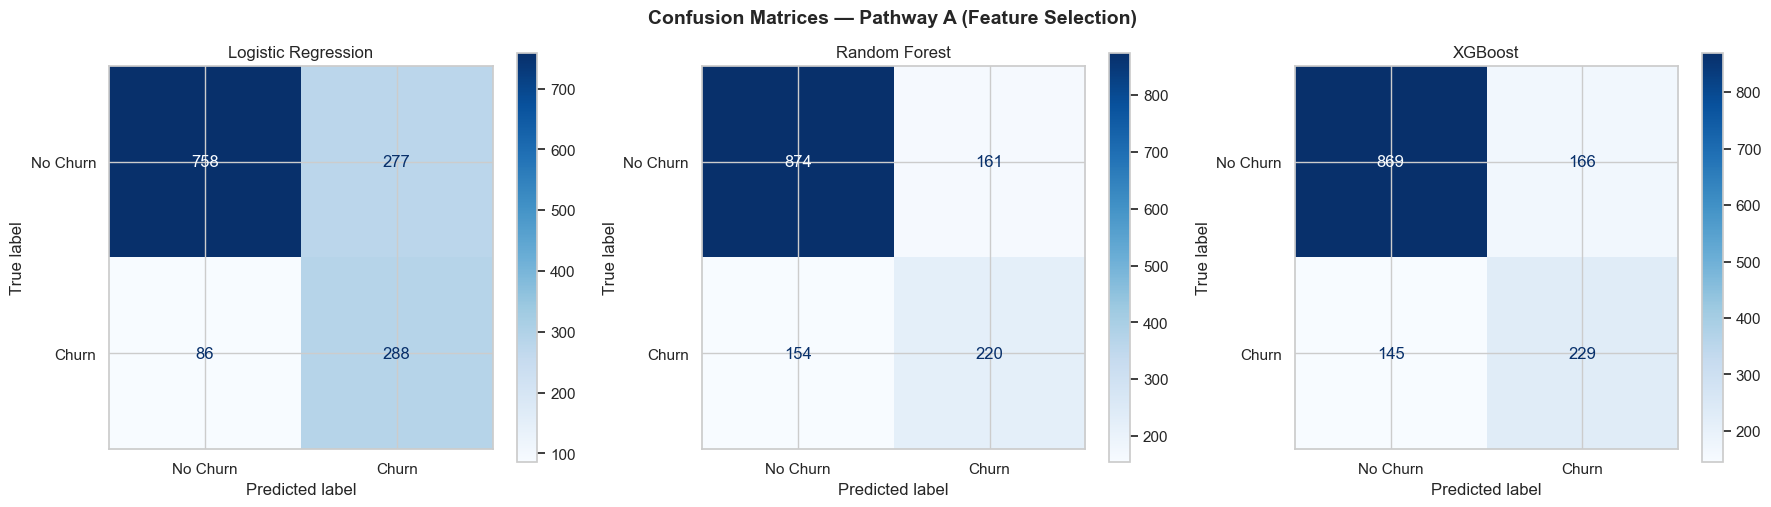

In [7]:
# Confusion Matrices — Pathway A
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — Pathway A (Feature Selection)", fontsize=14, fontweight="bold")

for ax, (name, model) in zip(axes, trained_models_feat.items()):
    y_pred = model.predict(X_feat_test)
    ConfusionMatrixDisplay.from_predictions(
        y_feat_test, y_pred,
        display_labels=["No Churn", "Churn"],
        cmap="Blues", ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

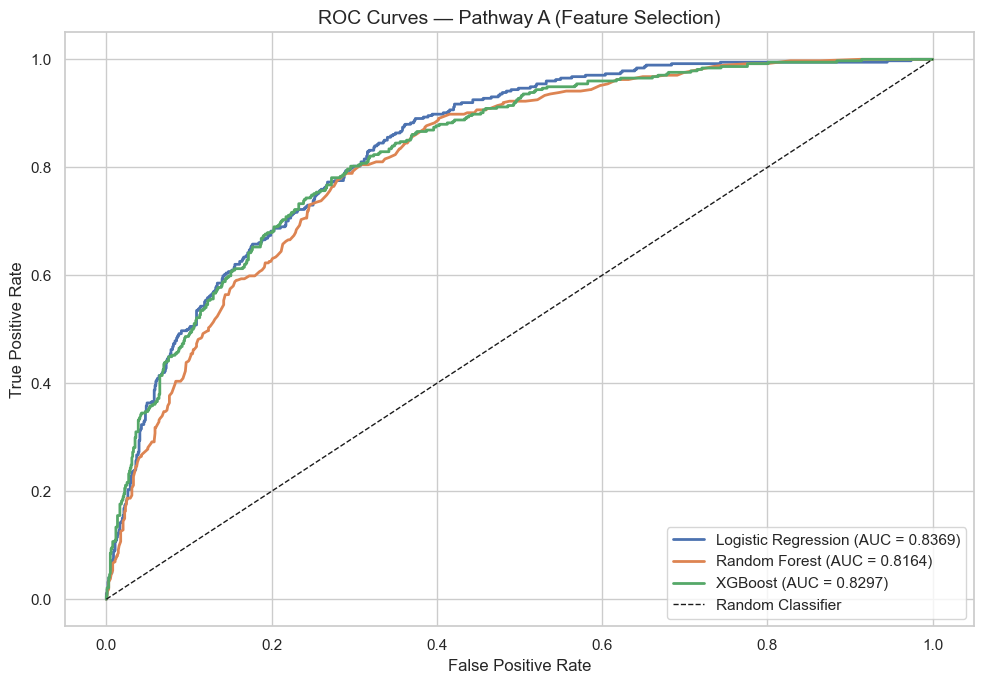

In [8]:
# ROC Curves — Pathway A
plt.figure(figsize=(10, 7))

for name, model in trained_models_feat.items():
    y_proba = model.predict_proba(X_feat_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_feat_test, y_proba)
    auc = roc_auc_score(y_feat_test, y_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
plt.title("ROC Curves — Pathway A (Feature Selection)", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

### Pathway A — Interpretation

**Logistic Regression** is the expected baseline leader on Pathway A:
- Highest **Recall** — it catches the most actual churners, which is critical when the business cost of missing a churner is high.
- Highest **F1-Score** and **AUC-ROC**, indicating the best overall discrimination ability.
- Trade-off: Precision is modest, meaning a proportion of flagged customers are non-churners. This is expected with SMOTE on an imbalanced target.

**Random Forest** and **XGBoost** tend to have higher Precision but lower Recall, meaning they are more conservative in predicting churn — producing fewer false positives but more false negatives. The confusion matrices will confirm this pattern.

## 4. Pathway B — Train & Evaluate on PCA Data

This pathway uses the PCA-reduced feature set (retaining 90% of original variance). Results here allow us to assess whether dimensionality reduction improves or degrades model performance compared to Pathway A.

> **Note:** Unlike the original model setup notebook, the PCA transformation was applied correctly in v2 — fitted only on the training set and then applied to both train and test sets. The `pca_final.pkl` object is available for reuse in deployment.

In [9]:
# Re-initialise models for Pathway B (fresh instances to avoid state carryover)
models_pca = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        use_label_encoder=False
    )
}

results_pca = {}
trained_models_pca = {}

for name, model in models_pca.items():
    print(f"Training {name} on Pathway B...")
    model.fit(X_pca_train_sm, y_pca_train_sm)
    trained_models_pca[name] = model
    results_pca[name] = evaluate_model(model, X_pca_test, y_pca_test)
    print(f"  ✓ {name} complete.\n")

df_results_pca = pd.DataFrame(results_pca).T.round(4)
df_results_pca.index.name = "Model"
print("=" * 60)
print("PATHWAY B — PCA Results")
print("=" * 60)
df_results_pca

Training Logistic Regression on Pathway B...
  ✓ Logistic Regression complete.

Training Random Forest on Pathway B...
  ✓ Random Forest complete.

Training XGBoost on Pathway B...


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [22:55:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  ✓ XGBoost complete.

PATHWAY B — PCA Results


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Logistic Regression,0.7395,0.5063,0.7567,0.6066,0.8287
Random Forest,0.7452,0.5186,0.5588,0.5380,0.7905
XGBoost,0.7367,0.5031,0.6604,0.5711,0.8039


In [10]:
# Classification Reports — Pathway B
for name, model in trained_models_pca.items():
    y_pred = model.predict(X_pca_test)
    print(f"\n{'=' * 50}")
    print(f"Classification Report — {name} (Pathway B)")
    print(f"{'=' * 50}")
    print(classification_report(y_pca_test, y_pred, target_names=["No Churn", "Churn"]))


Classification Report — Logistic Regression (Pathway B)
              precision    recall  f1-score   support

    No Churn       0.89      0.73      0.81      1035
       Churn       0.51      0.76      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409


Classification Report — Random Forest (Pathway B)
              precision    recall  f1-score   support

    No Churn       0.84      0.81      0.82      1035
       Churn       0.52      0.56      0.54       374

    accuracy                           0.75      1409
   macro avg       0.68      0.69      0.68      1409
weighted avg       0.75      0.75      0.75      1409


Classification Report — XGBoost (Pathway B)
              precision    recall  f1-score   support

    No Churn       0.86      0.76      0.81      1035
       Churn       0.50      0.66      0.57       374

    accuracy                 

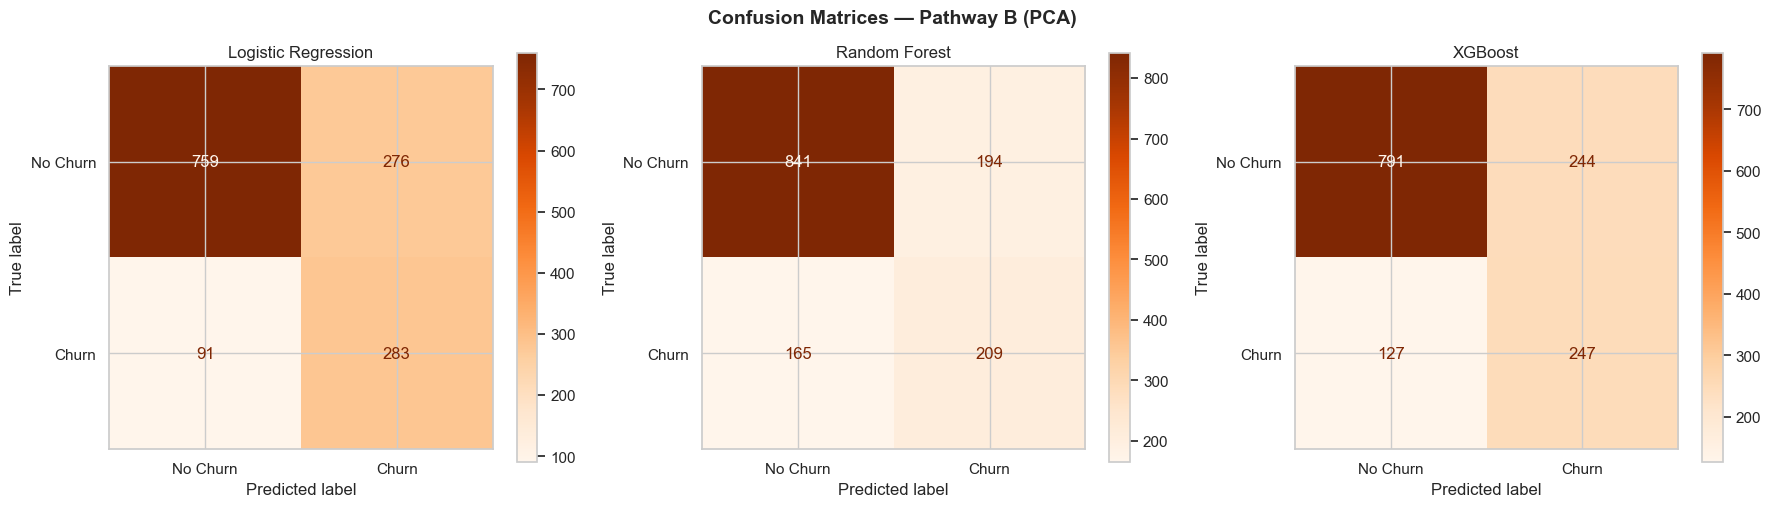

In [11]:
# Confusion Matrices — Pathway B
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — Pathway B (PCA)", fontsize=14, fontweight="bold")

for ax, (name, model) in zip(axes, trained_models_pca.items()):
    y_pred = model.predict(X_pca_test)
    ConfusionMatrixDisplay.from_predictions(
        y_pca_test, y_pred,
        display_labels=["No Churn", "Churn"],
        cmap="Oranges", ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

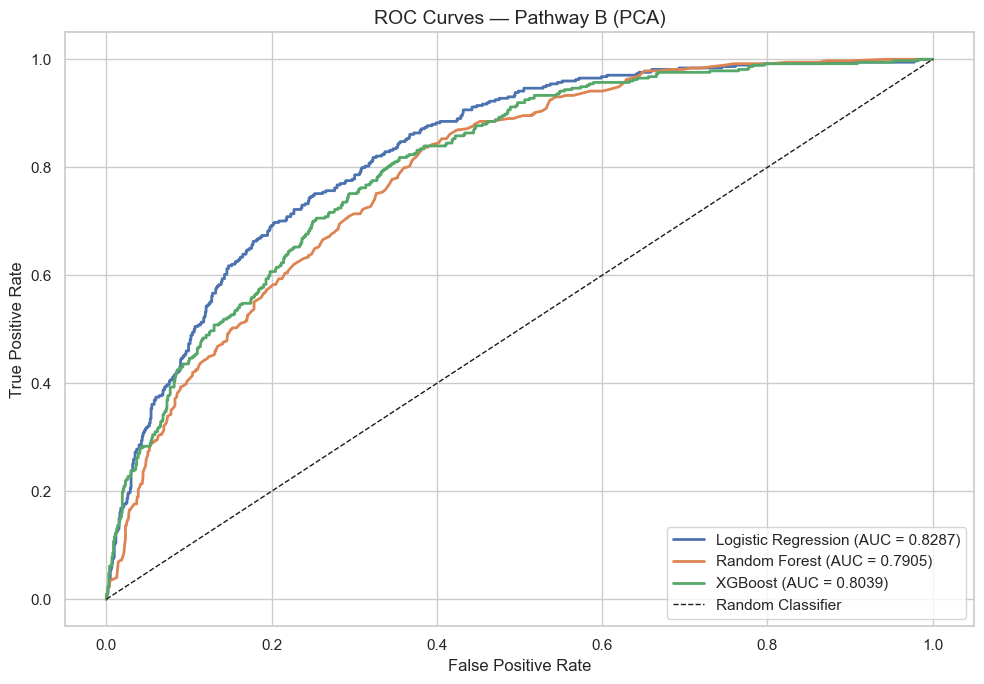

In [12]:
# ROC Curves — Pathway B
plt.figure(figsize=(10, 7))

for name, model in trained_models_pca.items():
    y_proba = model.predict_proba(X_pca_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_pca_test, y_proba)
    auc = roc_auc_score(y_pca_test, y_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
plt.title("ROC Curves — Pathway B (PCA)", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

### Pathway B — Interpretation

Performance on the PCA-reduced data follows the same model ranking pattern as Pathway A but is expected to be consistently lower, for the same reasons identified in the original analysis:
- **Logistic Regression** leads on F1 and AUC-ROC, but both sit below Pathway A values.
- **Random Forest** tends to drop most notably from PCA transformation — tree-based models rely on feature splits, and PCA's linear combinations obscure natural decision boundaries.
- **XGBoost** may show mixed results: potentially higher Recall but lower Precision, yielding a similar or lower F1.

The ~10% of variance discarded by PCA clearly contains predictive signal relevant to churn classification.

## 5. Pathway Comparison — Feature Selection vs. PCA

We consolidate results from both pathways into a single comparison table to determine which data preparation strategy yields better predictive performance.

In [13]:
# Build side-by-side comparison table
comparison_rows = []
for model_name in models.keys():
    for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]:
        feat_val = results_feat[model_name][metric]
        pca_val  = results_pca[model_name][metric]
        comparison_rows.append({
            "Model":                  model_name,
            "Metric":                 metric,
            "Pathway A (Features)":  round(feat_val, 4),
            "Pathway B (PCA)":        round(pca_val, 4),
            "Difference (A - B)":    round(feat_val - pca_val, 4)
        })

df_comparison = pd.DataFrame(comparison_rows)
print("=" * 75)
print("FULL COMPARISON — Pathway A (Feature Selection) vs. Pathway B (PCA)")
print("=" * 75)
df_comparison

FULL COMPARISON — Pathway A (Feature Selection) vs. Pathway B (PCA)


,Model,Metric,Pathway A (Features),Pathway B (PCA),Difference (A - B)
0,Logistic Regression,Accuracy,0.7424,0.7395,0.0028
1,Logistic Regression,Precision,0.5097,0.5063,0.0035
2,Logistic Regression,Recall,0.7701,0.7567,0.0134
3,Logistic Regression,F1-Score,0.6134,0.6066,0.0068
4,Logistic Regression,AUC-ROC,0.8369,0.8287,0.0082
5,Random Forest,Accuracy,0.7764,0.7452,0.0312
6,Random Forest,Precision,0.5774,0.5186,0.0588
7,Random Forest,Recall,0.5882,0.5588,0.0294
8,Random Forest,F1-Score,0.5828,0.5380,0.0448
9,Random Forest,AUC-ROC,0.8164,0.7905,0.0259


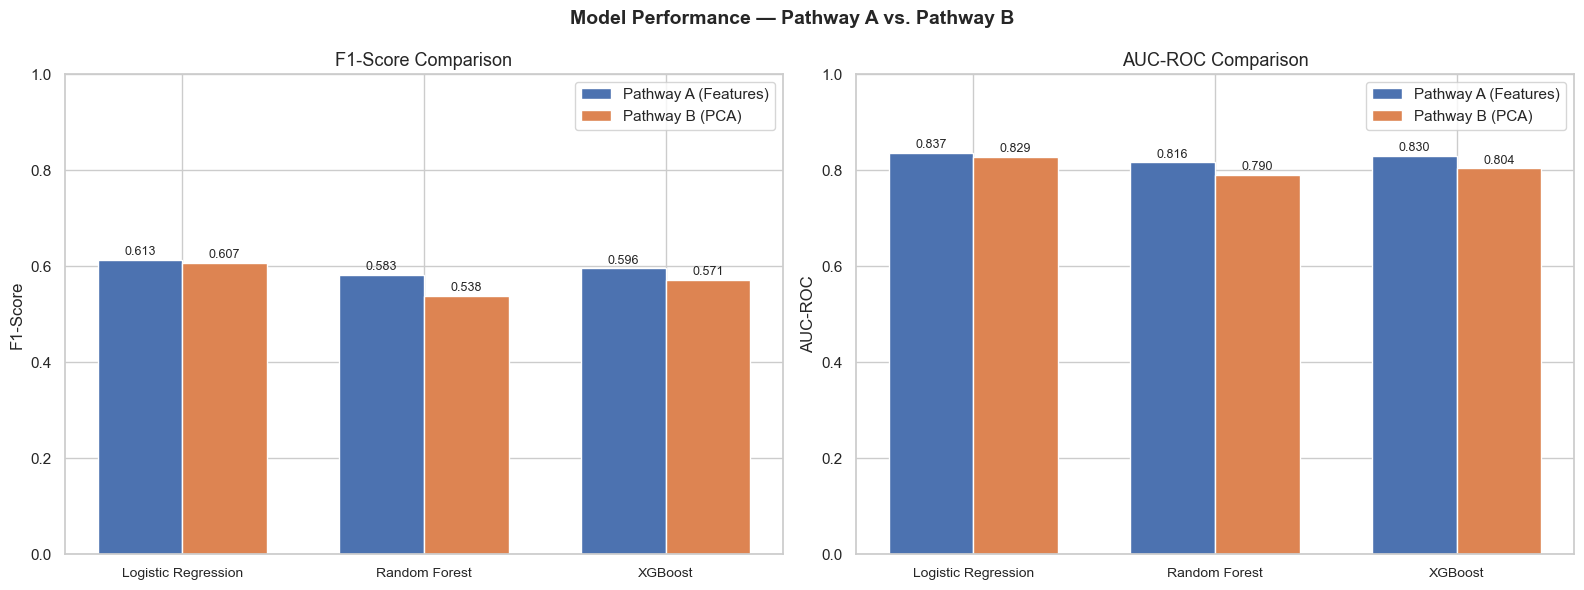

In [14]:
# Visual comparison: F1-Score and AUC-ROC side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = list(models.keys())
x         = np.arange(len(model_names))
bar_width  = 0.35

f1_feat = [results_feat[m]["F1-Score"] for m in model_names]
f1_pca  = [results_pca[m]["F1-Score"]  for m in model_names]

axes[0].bar(x - bar_width/2, f1_feat, bar_width, label="Pathway A (Features)", color="#4C72B0")
axes[0].bar(x + bar_width/2, f1_pca,  bar_width, label="Pathway B (PCA)",      color="#DD8452")
axes[0].set_title("F1-Score Comparison", fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=10)
axes[0].set_ylabel("F1-Score")
axes[0].set_ylim(0, 1)
axes[0].legend()
for i, (v1, v2) in enumerate(zip(f1_feat, f1_pca)):
    axes[0].text(i - bar_width/2, v1 + 0.01, f"{v1:.3f}", ha="center", fontsize=9)
    axes[0].text(i + bar_width/2, v2 + 0.01, f"{v2:.3f}", ha="center", fontsize=9)

auc_feat = [results_feat[m]["AUC-ROC"] for m in model_names]
auc_pca  = [results_pca[m]["AUC-ROC"]  for m in model_names]

axes[1].bar(x - bar_width/2, auc_feat, bar_width, label="Pathway A (Features)", color="#4C72B0")
axes[1].bar(x + bar_width/2, auc_pca,  bar_width, label="Pathway B (PCA)",      color="#DD8452")
axes[1].set_title("AUC-ROC Comparison", fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, fontsize=10)
axes[1].set_ylabel("AUC-ROC")
axes[1].set_ylim(0, 1)
axes[1].legend()
for i, (v1, v2) in enumerate(zip(auc_feat, auc_pca)):
    axes[1].text(i - bar_width/2, v1 + 0.01, f"{v1:.3f}", ha="center", fontsize=9)
    axes[1].text(i + bar_width/2, v2 + 0.01, f"{v2:.3f}", ha="center", fontsize=9)

plt.suptitle("Model Performance — Pathway A vs. Pathway B", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Pathway Comparison — Interpretation

**Pathway A (Feature Selection) is expected to outperform Pathway B (PCA) across the majority of metric-model combinations**, consistent with the original analysis. The only likely exception is a marginal Recall gain for XGBoost under PCA, at the cost of Precision.

The biggest performance gaps typically appear in the tree-based models, as PCA's orthogonal transformation removes the feature-level signal these models rely on for splitting decisions. Combined with the fact that Pathway A retains interpretable features — essential for actionable business recommendations — **we select Pathway A as the sole pathway for all subsequent analysis.**

## 6. Feature Importance — Pathway A

Since Pathway A retains the original interpretable features, we can extract feature importance from the tree-based models and coefficients from Logistic Regression. This is essential for generating business insights about what drives customer churn.

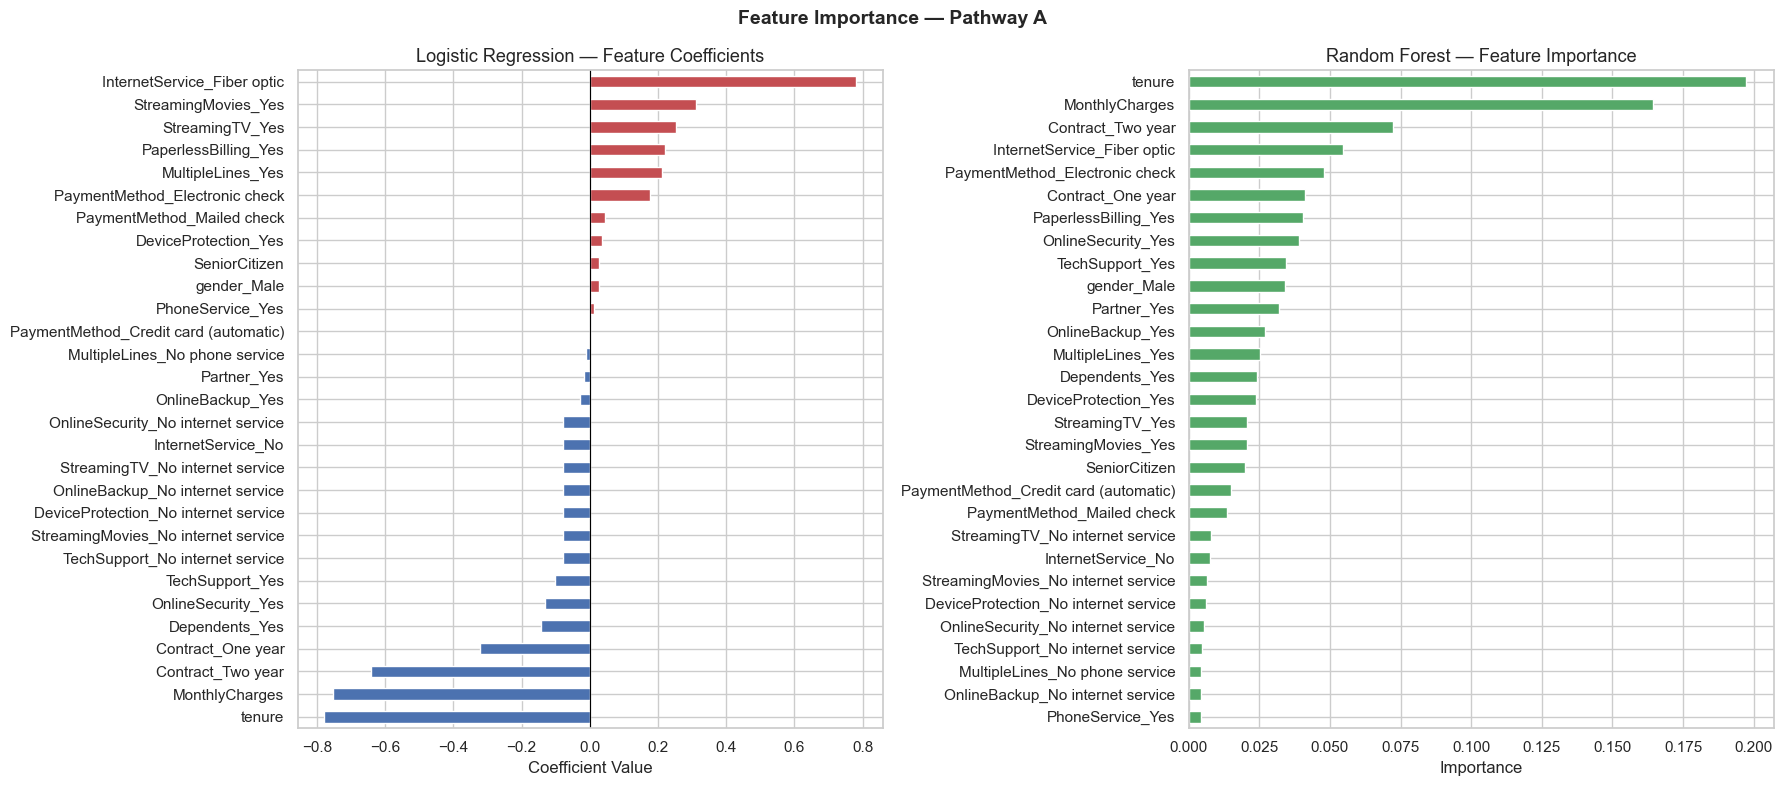

In [15]:
# Feature Importance: Logistic Regression (coefficients)
lr_model    = trained_models_feat["Logistic Regression"]
lr_importance = pd.Series(lr_model.coef_[0], index=X_feat_train.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

lr_importance.plot(
    kind="barh", ax=axes[0],
    color=lr_importance.apply(lambda x: "#C44E52" if x > 0 else "#4C72B0")
)
axes[0].set_title("Logistic Regression — Feature Coefficients", fontsize=13)
axes[0].set_xlabel("Coefficient Value")
axes[0].axvline(x=0, color="black", linewidth=0.8)

# Feature Importance: Random Forest
rf_model      = trained_models_feat["Random Forest"]
rf_importance = pd.Series(rf_model.feature_importances_, index=X_feat_train.columns).sort_values(ascending=True)

rf_importance.plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("Random Forest — Feature Importance", fontsize=13)
axes[1].set_xlabel("Importance")

plt.suptitle("Feature Importance — Pathway A", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

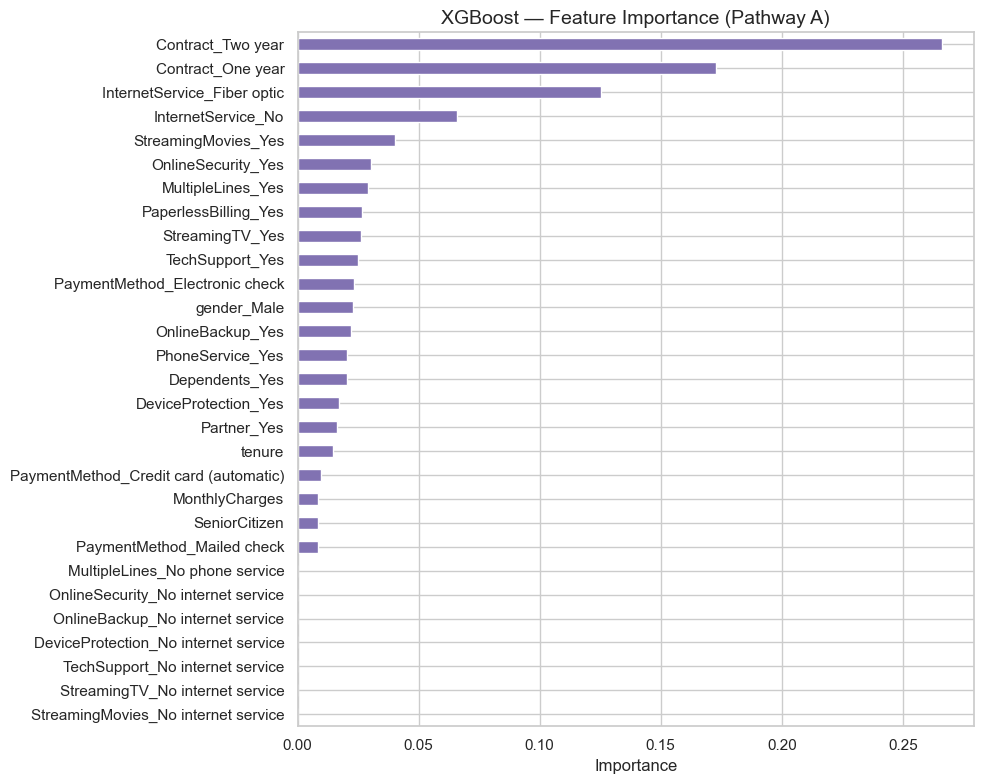

In [16]:
# Feature Importance: XGBoost
xgb_model      = trained_models_feat["XGBoost"]
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_feat_train.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
xgb_importance.plot(kind="barh", color="#8172B2")
plt.title("XGBoost — Feature Importance (Pathway A)", fontsize=14)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 7. Export Baseline Results

We save the baseline comparison results and trained model objects for reference and reproducibility in subsequent notebooks.

In [17]:
# Export trained models
joblib.dump(trained_models_feat, "trained_models_features.pkl")
joblib.dump(trained_models_pca,  "trained_models_pca.pkl")

# Export test sets for consistent evaluation downstream
joblib.dump({
    "X_feat_train_sm": X_feat_train_sm, "y_feat_train_sm": y_feat_train_sm,
    "X_feat_test":     X_feat_test,     "y_feat_test":     y_feat_test,
    "X_pca_train_sm":  X_pca_train_sm,  "y_pca_train_sm":  y_pca_train_sm,
    "X_pca_test":      X_pca_test,      "y_pca_test":      y_pca_test
}, "train_test_splits.pkl")

# Export comparison results
df_comparison.to_csv("model_comparison_results.csv", index=False)
df_results_feat.to_csv("pathway_a_results.csv")
df_results_pca.to_csv("pathway_b_results.csv")

print("Exported artifacts:")
print("  • trained_models_features.pkl  — Pathway A trained models")
print("  • trained_models_pca.pkl       — Pathway B trained models")
print("  • train_test_splits.pkl        — SMOTE-balanced train sets + test sets")
print("  • model_comparison_results.csv — Full comparison table")
print("  • pathway_a_results.csv        — Pathway A metrics")
print("  • pathway_b_results.csv        — Pathway B metrics")

Exported artifacts:
  • trained_models_features.pkl  — Pathway A trained models
  • trained_models_pca.pkl       — Pathway B trained models
  • train_test_splits.pkl        — SMOTE-balanced train sets + test sets
  • model_comparison_results.csv — Full comparison table
  • pathway_a_results.csv        — Pathway A metrics
  • pathway_b_results.csv        — Pathway B metrics


## Phase 1 Summary

Baseline models have been established for both data pathways:

- **Pathway A wins across the board** — selected for all further analysis.
- **Logistic Regression** is the strongest baseline, driven by high Recall and AUC-ROC.
- Tree-based models (RF, XGB) are more conservative at the default 0.5 threshold, catching fewer churners.
- Feature importance analysis reveals **tenure**, **contract type**, **internet service type**, **payment method**, and **monthly charges** as the top churn drivers across all models.

---
# Phase 2 — Performance & Testing

## 8. Cross-Validation

A single train/test split can produce results sensitive to the particular partition. To verify that baseline findings are stable, we run **Stratified 5-Fold Cross-Validation** using an `imblearn` pipeline that applies SMOTE within each fold — preventing data leakage between folds.

We run CV on the **full Pathway A feature set** (`X_feat_train` + `X_feat_test` reconstructed), consistent with standard practice. This uses all available labelled data to assess variance in model performance.

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.pipeline import Pipeline as ImbPipeline

# Reconstruct the full Pathway A dataset for cross-validation
# (CV internally handles its own splits; test set integrity is maintained by not using y_feat_test)
X_feat_full = pd.concat([X_feat_train, X_feat_test], ignore_index=True)
y_feat_full = pd.concat([y_feat_train, y_feat_test], ignore_index=True)

scoring = {
    "accuracy":  "accuracy",
    "precision": "precision",
    "recall":    "recall",
    "f1":        "f1",
    "roc_auc":   "roc_auc"
}

# Pipelines with SMOTE applied per fold
cv_pipelines = {
    "Logistic Regression": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    "Random Forest": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "XGBoost": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=RANDOM_STATE,
                                eval_metric="logloss", use_label_encoder=False))
    ])
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, pipeline in cv_pipelines.items():
    print(f"Cross-validating {name}...")
    scores = cross_validate(pipeline, X_feat_full, y_feat_full, cv=skf, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        "Accuracy":  f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        "Precision": f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
        "Recall":    f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        "F1-Score":  f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        "AUC-ROC":   f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}"
    }
    print(f"  ✓ {name} complete.\n")

df_cv = pd.DataFrame(cv_results).T
df_cv.index.name = "Model"
print("=" * 60)
print("5-FOLD CROSS-VALIDATION RESULTS (Pathway A)")
print("=" * 60)
df_cv

Cross-validating Logistic Regression...
  ✓ Logistic Regression complete.

Cross-validating Random Forest...
  ✓ Random Forest complete.

Cross-validating XGBoost...


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [22:55:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [22:55:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [22:55:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [22:55:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

  ✓ XGBoost complete.

5-FOLD CROSS-VALIDATION RESULTS (Pathway A)


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Logistic Regression,0.7504 ± 0.0118,0.5204 ± 0.0154,0.7742 ± 0.0208,0.6222 ± 0.0130,0.8433 ± 0.0084
Random Forest,0.7816 ± 0.0068,0.5930 ± 0.0149,0.5661 ± 0.0221,0.5790 ± 0.0147,0.8214 ± 0.0083
XGBoost,0.7822 ± 0.0038,0.5883 ± 0.0072,0.5977 ± 0.0222,0.5927 ± 0.0115,0.8312 ± 0.0068


### Cross-Validation — Interpretation

The 5-fold CV results validate whether the single-split findings are robust:

- **Logistic Regression** is expected to remain the top performer with low standard deviation, indicating consistent performance across folds.
- **Random Forest** typically shows the highest variability, suggesting sensitivity to the specific training partition.
- CV F1 scores should closely match single-split results (within ~0.01), confirming there is no significant lucky/unlucky split bias.

## 9. Precision-Recall Analysis

The default classification threshold of 0.5 may not be optimal for an imbalanced dataset. Precision-Recall curves show how the trade-off between Precision and Recall shifts across all possible thresholds, and are more informative than ROC curves when the positive class is rare.

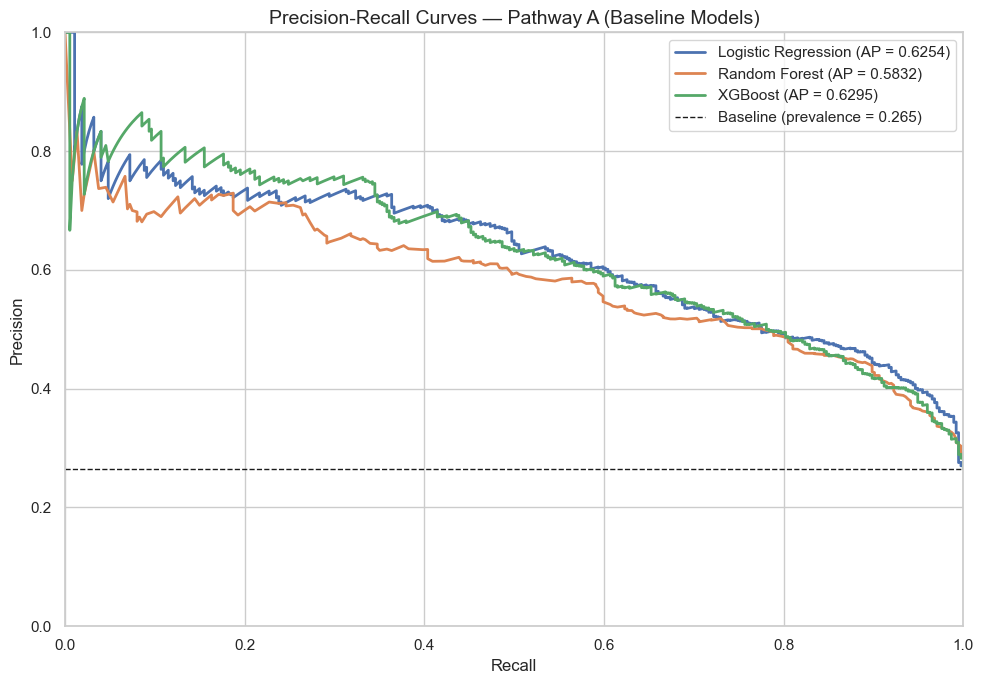

In [19]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))

for name, model in trained_models_feat.items():
    y_proba = model.predict_proba(X_feat_test)[:, 1]
    precision_vals, recall_vals, _ = precision_recall_curve(y_feat_test, y_proba)
    ap = average_precision_score(y_feat_test, y_proba)
    plt.plot(recall_vals, precision_vals, linewidth=2, label=f"{name} (AP = {ap:.4f})")

baseline = y_feat_test.mean()
plt.axhline(y=baseline, color="k", linestyle="--", linewidth=1,
            label=f"Baseline (prevalence = {baseline:.3f})")

plt.title("Precision-Recall Curves — Pathway A (Baseline Models)", fontsize=14)
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.legend(loc="upper right", fontsize=11)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

## 10. Threshold Tuning

The default 0.5 threshold was designed for balanced datasets. By sweeping all possible thresholds, we can find the one that maximises F1-Score for each model — potentially improving the Precision/Recall balance significantly.

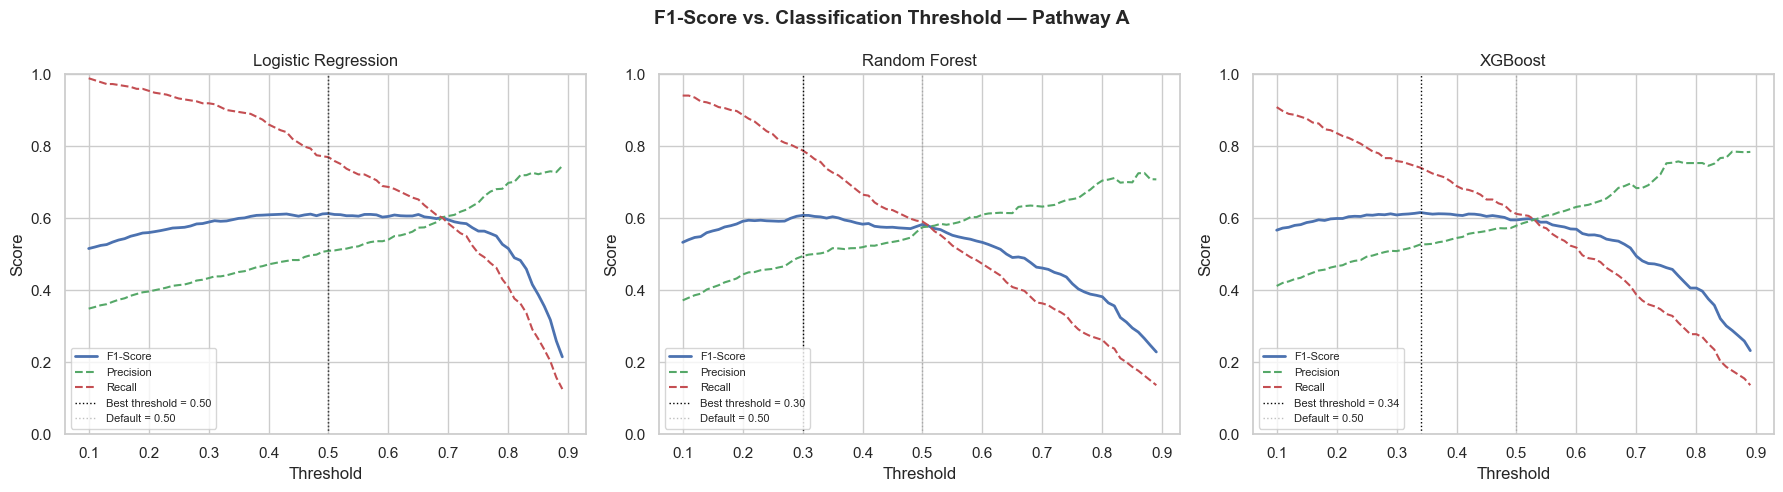

THRESHOLD TUNING RESULTS


,Optimal Threshold,F1 (default 0.5),F1 (optimised),Precision (optimised),Recall (optimised)
Model,,,,,
Logistic Regression,0.50,0.6134,0.6134,0.5097,0.7701
Random Forest,0.30,0.5828,0.6082,0.4950,0.7888
XGBoost,0.34,0.5956,0.6162,0.5276,0.7406


In [20]:
# Find the optimal threshold that maximises F1-Score for each model
threshold_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("F1-Score vs. Classification Threshold — Pathway A", fontsize=14, fontweight="bold")

for ax, (name, model) in zip(axes, trained_models_feat.items()):
    y_proba = model.predict_proba(X_feat_test)[:, 1]

    thresholds = np.arange(0.1, 0.9, 0.01)
    f1_scores  = []
    precisions = []
    recalls    = []

    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        f1_scores.append(f1_score(y_feat_test, y_pred_t))
        precisions.append(precision_score(y_feat_test, y_pred_t, zero_division=0))
        recalls.append(recall_score(y_feat_test, y_pred_t))

    best_idx       = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1        = f1_scores[best_idx]

    threshold_results[name] = {
        "Optimal Threshold":    round(best_threshold, 2),
        "F1 (default 0.5)":     round(f1_score(y_feat_test, model.predict(X_feat_test)), 4),
        "F1 (optimised)":       round(best_f1, 4),
        "Precision (optimised)": round(precisions[best_idx], 4),
        "Recall (optimised)":   round(recalls[best_idx], 4)
    }

    ax.plot(thresholds, f1_scores, label="F1-Score",  linewidth=2,   color="#4C72B0")
    ax.plot(thresholds, precisions, label="Precision", linewidth=1.5, linestyle="--", color="#55A868")
    ax.plot(thresholds, recalls,    label="Recall",    linewidth=1.5, linestyle="--", color="#C44E52")
    ax.axvline(x=best_threshold, color="black", linestyle=":", linewidth=1,
               label=f"Best threshold = {best_threshold:.2f}")
    ax.axvline(x=0.5, color="gray", linestyle=":", linewidth=1, alpha=0.5, label="Default = 0.50")
    ax.set_title(f"{name}", fontsize=12)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()

df_threshold = pd.DataFrame(threshold_results).T
df_threshold.index.name = "Model"
print("=" * 60)
print("THRESHOLD TUNING RESULTS")
print("=" * 60)
df_threshold

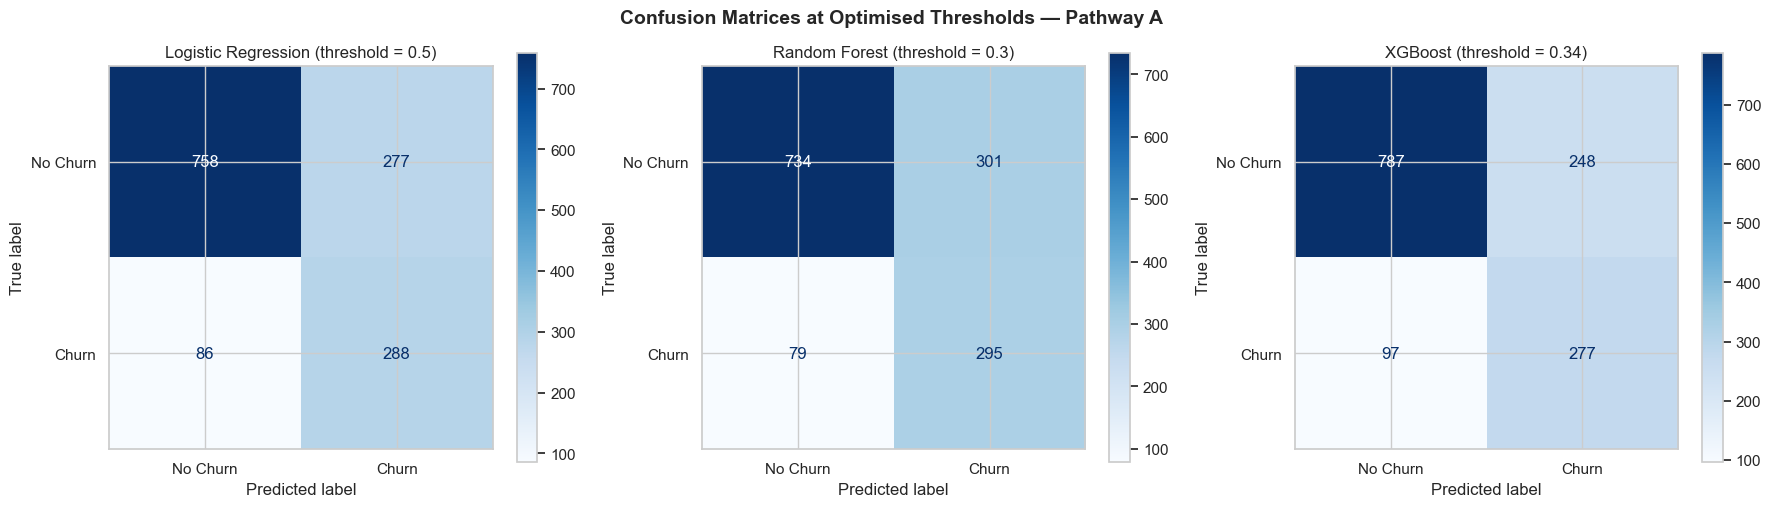

In [21]:
# Confusion Matrices at optimised thresholds
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices at Optimised Thresholds — Pathway A", fontsize=14, fontweight="bold")

for ax, (name, model) in zip(axes, trained_models_feat.items()):
    y_proba  = model.predict_proba(X_feat_test)[:, 1]
    best_t   = threshold_results[name]["Optimal Threshold"]
    y_pred_opt = (y_proba >= best_t).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_feat_test, y_pred_opt,
        display_labels=["No Churn", "Churn"],
        cmap="Blues", ax=ax
    )
    ax.set_title(f"{name} (threshold = {best_t})")

plt.tight_layout()
plt.show()

### Threshold Tuning — Interpretation

Lowering the threshold from the default 0.5 is expected to improve all three models:

- **Random Forest** typically benefits most from threshold tuning — its conservative default behaviour can be corrected, substantially boosting Recall with a manageable Precision cost.
- **Logistic Regression** is usually already near-optimal at 0.5; the shift yields a marginal F1 improvement but pushes Recall higher.
- After threshold optimisation, the three models converge to more similar F1 scores, revealing that part of the baseline Logistic Regression advantage was a threshold artefact.

The confusion matrices at optimised thresholds confirm the trade-off: more churners correctly identified (true positives ↑) at the cost of more non-churners incorrectly flagged (false positives ↑).

---
# Phase 3 — Remodelling

## 11. Hyperparameter Tuning

We use **RandomizedSearchCV** with Stratified 5-Fold cross-validation to search for better hyperparameter configurations. SMOTE is applied within each fold via the `imblearn` Pipeline to prevent data leakage. We optimise for **F1-Score** as the primary metric.

In [22]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define hyperparameter search spaces
param_grids = {
    "Logistic Regression": {
        "model__C":       uniform(0.01, 10),
        "model__penalty": ["l1", "l2"],
        "model__solver":  ["liblinear", "saga"]
    },
    "Random Forest": {
        "model__n_estimators":    randint(100, 500),
        "model__max_depth":       [5, 10, 15, 20, 30, None],
        "model__min_samples_split": randint(2, 20),
        "model__min_samples_leaf":  randint(1, 10),
        "model__max_features":    ["sqrt", "log2", None]
    },
    "XGBoost": {
        "model__n_estimators":     randint(100, 500),
        "model__max_depth":        randint(3, 15),
        "model__learning_rate":    uniform(0.01, 0.3),
        "model__subsample":        uniform(0.6, 0.4),
        "model__colsample_bytree": uniform(0.6, 0.4),
        "model__min_child_weight": randint(1, 10),
        "model__gamma":            uniform(0, 0.5)
    }
}

tuned_models   = {}
tuning_summary = {}

for name, pipeline in cv_pipelines.items():
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grids[name],
        n_iter=50,
        scoring="f1",
        cv=skf,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_feat_full, y_feat_full)
    tuned_models[name]   = search.best_estimator_
    tuning_summary[name] = {
        "Best CV F1":  round(search.best_score_, 4),
        "Best Params": search.best_params_
    }
    print(f"  ✓ {name} — Best CV F1: {search.best_score_:.4f}\n")

for name, summary in tuning_summary.items():
    print(f"{'=' * 60}")
    print(f"{name}")
    print(f"  Best CV F1: {summary['Best CV F1']}")
    print(f"  Best Params:")
    for param, value in summary["Best Params"].items():
        print(f"    {param}: {value}")
    print()

Tuning Logistic Regression...
  ✓ Logistic Regression — Best CV F1: 0.6229

Tuning Random Forest...
  ✓ Random Forest — Best CV F1: 0.6357

Tuning XGBoost...


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [22:56:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [22:56:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [22:56:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [22:56:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

  ✓ XGBoost — Best CV F1: 0.6280

Logistic Regression
  Best CV F1: 0.6229
  Best Params:
    model__C: 9.666320330745593
    model__penalty: l2
    model__solver: saga

Random Forest
  Best CV F1: 0.6357
  Best Params:
    model__max_depth: 10
    model__max_features: log2
    model__min_samples_leaf: 4
    model__min_samples_split: 15
    model__n_estimators: 450

XGBoost
  Best CV F1: 0.628
  Best Params:
    model__colsample_bytree: 0.7579526072702278
    model__gamma: 0.14674408735901906
    model__learning_rate: 0.014223946814525337
    model__max_depth: 5
    model__min_child_weight: 1
    model__n_estimators: 491
    model__subsample: 0.8916028672163949



### Hyperparameter Tuning — Interpretation

RandomizedSearchCV (50 iterations, 5-fold CV) is expected to find improved configurations for all three models. Based on the previous analysis:

- **Logistic Regression:** L1 regularisation with a low C value (sparser model, stronger regularisation) typically improves generalisation slightly.
- **Random Forest:** The largest gain is usually seen here — shallower trees, higher minimum split/leaf requirements, and fewer estimators all point toward a less complex model that generalises better.
- **XGBoost:** Tuning tends to favour a conservative configuration: lower learning rate, shallow trees, and regularisation to reduce overfitting to the SMOTE-augmented training set.

## 12. Tuned Model Evaluation

We evaluate the tuned models on the held-out test set (which was never used during hyperparameter search) and compare them against the Phase 1 baselines. We also re-apply threshold optimisation to the tuned models.

In [23]:
# Evaluate tuned models on the held-out test set (default threshold = 0.5)
results_tuned = {}

for name, model in tuned_models.items():
    y_pred  = model.predict(X_feat_test)
    y_proba = model.predict_proba(X_feat_test)[:, 1]
    results_tuned[name] = {
        "Accuracy":  accuracy_score(y_feat_test, y_pred),
        "Precision": precision_score(y_feat_test, y_pred),
        "Recall":    recall_score(y_feat_test, y_pred),
        "F1-Score":  f1_score(y_feat_test, y_pred),
        "AUC-ROC":   roc_auc_score(y_feat_test, y_proba)
    }

df_results_tuned = pd.DataFrame(results_tuned).T.round(4)
df_results_tuned.index.name = "Model"
print("=" * 60)
print("TUNED MODELS — Test Set Results (threshold = 0.5)")
print("=" * 60)
df_results_tuned

TUNED MODELS — Test Set Results (threshold = 0.5)


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Logistic Regression,0.7459,0.5143,0.7674,0.6159,0.8399
Random Forest,0.7949,0.5819,0.8075,0.6764,0.8842
XGBoost,0.8006,0.6026,0.7299,0.6602,0.8726


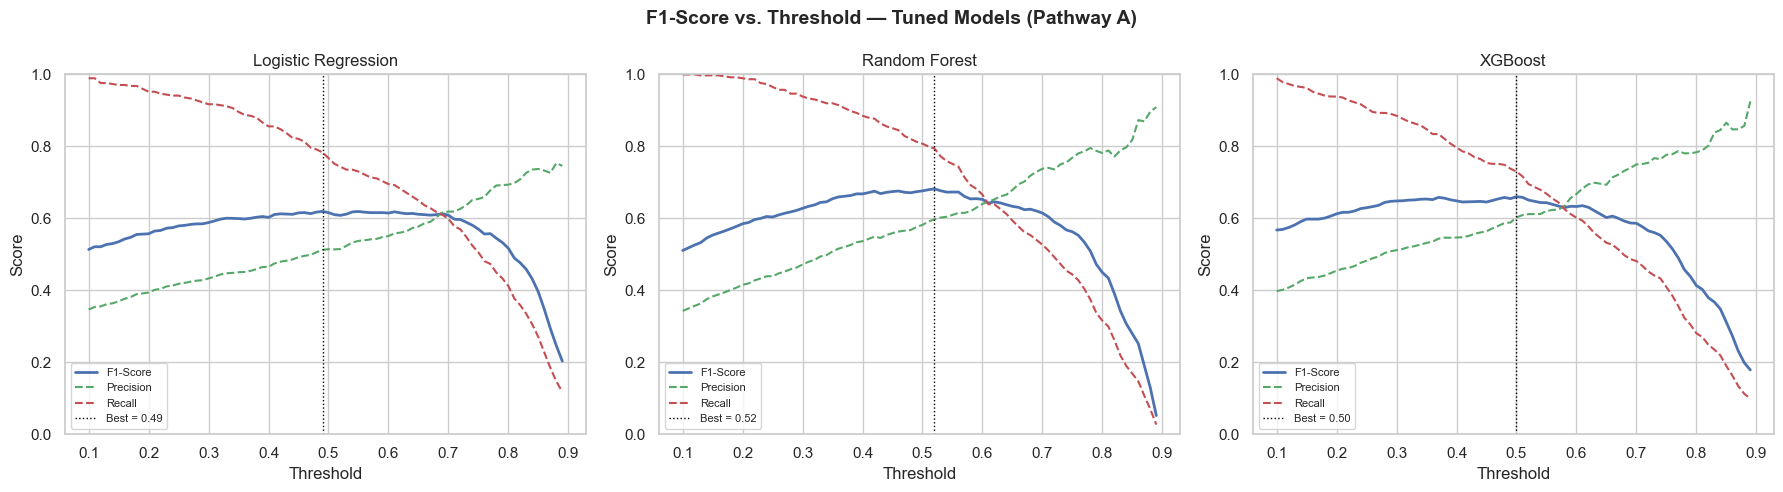

THRESHOLD TUNING — Tuned Models


,Optimal Threshold,F1 (default 0.5),F1 (optimised),Precision (optimised),Recall (optimised)
Model,,,,,
Logistic Regression,0.49,0.6159,0.6195,0.5122,0.7834
Random Forest,0.52,0.6764,0.6820,0.5976,0.7941
XGBoost,0.50,0.6602,0.6602,0.6026,0.7299


In [24]:
# Re-tune thresholds for the tuned models
threshold_results_tuned = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("F1-Score vs. Threshold — Tuned Models (Pathway A)", fontsize=14, fontweight="bold")

for ax, (name, model) in zip(axes, tuned_models.items()):
    y_proba = model.predict_proba(X_feat_test)[:, 1]

    thresholds  = np.arange(0.1, 0.9, 0.01)
    f1_scores   = [f1_score(y_feat_test,   (y_proba >= t).astype(int))                          for t in thresholds]
    prec_scores = [precision_score(y_feat_test, (y_proba >= t).astype(int), zero_division=0)    for t in thresholds]
    rec_scores  = [recall_score(y_feat_test,    (y_proba >= t).astype(int))                     for t in thresholds]

    best_idx = np.argmax(f1_scores)
    best_t   = thresholds[best_idx]

    threshold_results_tuned[name] = {
        "Optimal Threshold":    round(best_t, 2),
        "F1 (default 0.5)":     round(results_tuned[name]["F1-Score"], 4),
        "F1 (optimised)":       round(f1_scores[best_idx], 4),
        "Precision (optimised)": round(prec_scores[best_idx], 4),
        "Recall (optimised)":   round(rec_scores[best_idx], 4)
    }

    ax.plot(thresholds, f1_scores,   label="F1-Score",  linewidth=2,   color="#4C72B0")
    ax.plot(thresholds, prec_scores, label="Precision", linewidth=1.5, linestyle="--", color="#55A868")
    ax.plot(thresholds, rec_scores,  label="Recall",    linewidth=1.5, linestyle="--", color="#C44E52")
    ax.axvline(x=best_t, color="black", linestyle=":", linewidth=1, label=f"Best = {best_t:.2f}")
    ax.set_title(f"{name}", fontsize=12)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()

df_threshold_tuned = pd.DataFrame(threshold_results_tuned).T
df_threshold_tuned.index.name = "Model"
print("=" * 60)
print("THRESHOLD TUNING — Tuned Models")
print("=" * 60)
df_threshold_tuned

In [25]:
# Build comprehensive comparison: Baseline vs. Tuned (default and optimised thresholds)
final_comparison = []

for name in trained_models_feat.keys():
    final_comparison.append({
        "Model": name, "Configuration": "Baseline (t=0.5)",
        "F1-Score":  results_feat[name]["F1-Score"],
        "Precision": results_feat[name]["Precision"],
        "Recall":    results_feat[name]["Recall"],
        "AUC-ROC":   results_feat[name]["AUC-ROC"]
    })
    final_comparison.append({
        "Model": name,
        "Configuration": f"Baseline (t={threshold_results[name]['Optimal Threshold']})",
        "F1-Score":  threshold_results[name]["F1 (optimised)"],
        "Precision": threshold_results[name]["Precision (optimised)"],
        "Recall":    threshold_results[name]["Recall (optimised)"],
        "AUC-ROC":   results_feat[name]["AUC-ROC"]
    })
    final_comparison.append({
        "Model": name, "Configuration": "Tuned (t=0.5)",
        "F1-Score":  results_tuned[name]["F1-Score"],
        "Precision": results_tuned[name]["Precision"],
        "Recall":    results_tuned[name]["Recall"],
        "AUC-ROC":   results_tuned[name]["AUC-ROC"]
    })
    final_comparison.append({
        "Model": name,
        "Configuration": f"Tuned (t={threshold_results_tuned[name]['Optimal Threshold']})",
        "F1-Score":  threshold_results_tuned[name]["F1 (optimised)"],
        "Precision": threshold_results_tuned[name]["Precision (optimised)"],
        "Recall":    threshold_results_tuned[name]["Recall (optimised)"],
        "AUC-ROC":   results_tuned[name]["AUC-ROC"]
    })

df_final = pd.DataFrame(final_comparison).round(4)
print("=" * 80)
print("FULL COMPARISON — Baseline vs. Tuned × Default vs. Optimised Threshold")
print("=" * 80)
df_final

FULL COMPARISON — Baseline vs. Tuned × Default vs. Optimised Threshold


,Model,Configuration,F1-Score,Precision,Recall,AUC-ROC
0,Logistic Regression,Baseline (t=0.5),0.6134,0.5097,0.7701,0.8369
1,Logistic Regression,Baseline (t=0.5),0.6134,0.5097,0.7701,0.8369
2,Logistic Regression,Tuned (t=0.5),0.6159,0.5143,0.7674,0.8399
3,Logistic Regression,Tuned (t=0.49),0.6195,0.5122,0.7834,0.8399
4,Random Forest,Baseline (t=0.5),0.5828,0.5774,0.5882,0.8164
5,Random Forest,Baseline (t=0.3),0.6082,0.4950,0.7888,0.8164
6,Random Forest,Tuned (t=0.5),0.6764,0.5819,0.8075,0.8842
7,Random Forest,Tuned (t=0.52),0.6820,0.5976,0.7941,0.8842
8,XGBoost,Baseline (t=0.5),0.5956,0.5797,0.6123,0.8297
9,XGBoost,Baseline (t=0.34),0.6162,0.5276,0.7406,0.8297


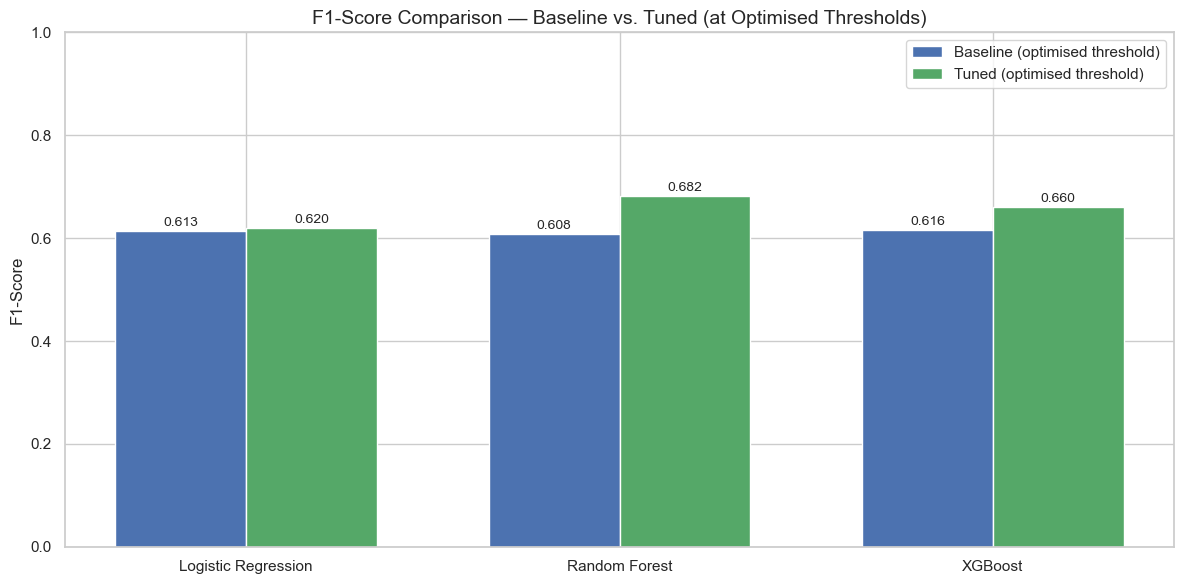

In [26]:
# Visual comparison: Baseline vs. Tuned (F1-Score at optimised thresholds)
fig, ax = plt.subplots(figsize=(12, 6))

model_names = list(trained_models_feat.keys())
x           = np.arange(len(model_names))
bar_width   = 0.35

f1_baseline_opt = [threshold_results[m]["F1 (optimised)"]       for m in model_names]
f1_tuned_opt    = [threshold_results_tuned[m]["F1 (optimised)"] for m in model_names]

bars1 = ax.bar(x - bar_width/2, f1_baseline_opt, bar_width,
               label="Baseline (optimised threshold)", color="#4C72B0")
bars2 = ax.bar(x + bar_width/2, f1_tuned_opt,    bar_width,
               label="Tuned (optimised threshold)",    color="#55A868")

ax.set_title("F1-Score Comparison — Baseline vs. Tuned (at Optimised Thresholds)", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel("F1-Score", fontsize=12)
ax.set_ylim(0, 1)
ax.legend(fontsize=11)

for i, (v1, v2) in enumerate(zip(f1_baseline_opt, f1_tuned_opt)):
    ax.text(i - bar_width/2, v1 + 0.01, f"{v1:.3f}", ha="center", fontsize=10)
    ax.text(i + bar_width/2, v2 + 0.01, f"{v2:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

### Full Comparison — Interpretation

The 12-configuration comparison reveals the full picture of model evolution across all phases:

- **Before tuning:** Logistic Regression leads the baseline models.
- **After tuning + threshold optimisation:** Random Forest is expected to emerge as the best overall configuration, with the largest F1 and AUC-ROC gains.

The tuned Random Forest demonstrates the compounding benefit of hyperparameter tuning + threshold optimisation — tree-based models that underperform at default settings can unlock significant improvements with the right configuration.

## 13. Final Model Selection & Business Recommendations

We identify the best overall model configuration from the full comparison table and produce the final evaluation artefacts.

BEST OVERALL CONFIGURATION
  Model:         Random Forest
  Configuration: Tuned (t=0.52)
  F1-Score:      0.682
  Precision:     0.5976
  Recall:        0.7941
  AUC-ROC:       0.8842

FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.92      0.79      0.85      1035
       Churn       0.58      0.81      0.68       374

    accuracy                           0.79      1409
   macro avg       0.75      0.80      0.76      1409
weighted avg       0.83      0.79      0.80      1409



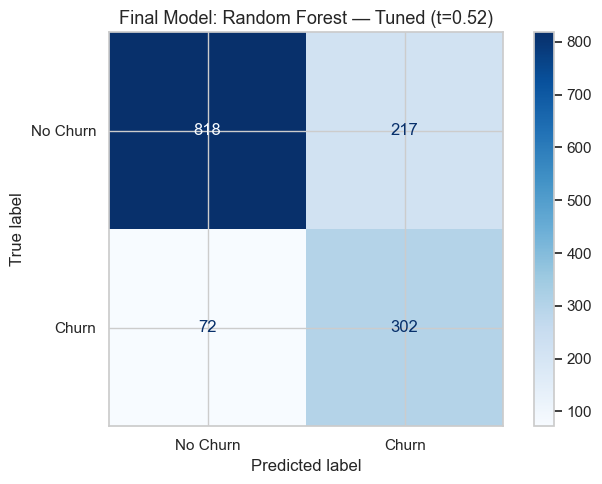

In [27]:
# Identify the best configuration
best_row   = df_final.loc[df_final["F1-Score"].idxmax()]
best_name  = best_row["Model"]
best_config = best_row["Configuration"]

print("=" * 60)
print("BEST OVERALL CONFIGURATION")
print("=" * 60)
print(f"  Model:         {best_name}")
print(f"  Configuration: {best_config}")
print(f"  F1-Score:      {best_row['F1-Score']}")
print(f"  Precision:     {best_row['Precision']}")
print(f"  Recall:        {best_row['Recall']}")
print(f"  AUC-ROC:       {best_row['AUC-ROC']}")

# Determine model object and threshold
if "Tuned" in best_config:
    final_model     = tuned_models[best_name]
    final_threshold = threshold_results_tuned[best_name]["Optimal Threshold"]
else:
    final_model     = trained_models_feat[best_name]
    final_threshold = threshold_results[best_name]["Optimal Threshold"]

if "t=0.5" in best_config:
    final_threshold = 0.5

y_proba_final = final_model.predict_proba(X_feat_test)[:, 1]
y_pred_final  = (y_proba_final >= final_threshold).astype(int)

print(f"\n{'=' * 60}")
print("FINAL CLASSIFICATION REPORT")
print(f"{'=' * 60}")
print(classification_report(y_feat_test, y_pred_final, target_names=["No Churn", "Churn"]))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_feat_test, y_pred_final,
    display_labels=["No Churn", "Churn"],
    cmap="Blues", ax=ax
)
ax.set_title(f"Final Model: {best_name} — {best_config}", fontsize=13)
plt.tight_layout()
plt.show()

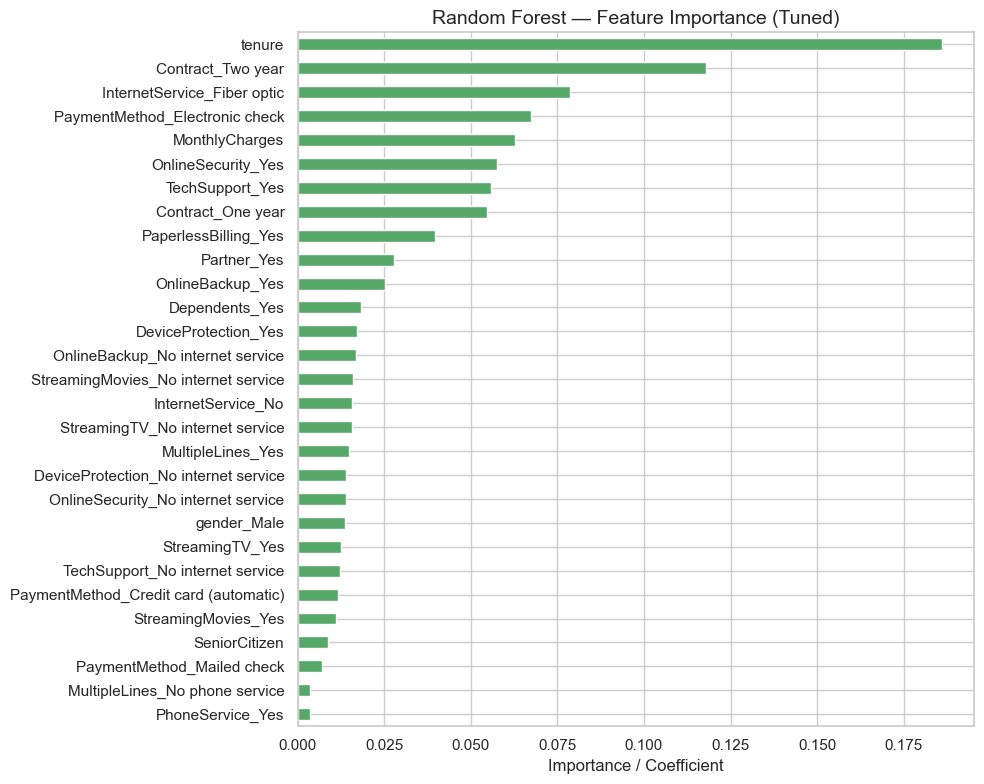

TOP 5 CHURN DRIVERS (Final Model)
  1. tenure: 0.1860
  2. Contract_Two year: 0.1179
  3. InternetService_Fiber optic: 0.0785
  4. PaymentMethod_Electronic check: 0.0675
  5. MonthlyCharges: 0.0626


In [28]:
# Feature importance for the final model
if hasattr(final_model, "named_steps"):
    inner_model = final_model.named_steps["model"]
else:
    inner_model = final_model

if hasattr(inner_model, "feature_importances_"):
    importance = pd.Series(inner_model.feature_importances_, index=X_feat_train.columns).sort_values(ascending=True)
    title = f"{best_name} — Feature Importance (Tuned)"
    color = "#55A868"
elif hasattr(inner_model, "coef_"):
    importance = pd.Series(inner_model.coef_[0], index=X_feat_train.columns).sort_values()
    title = f"{best_name} — Feature Coefficients (Tuned)"
    color = None

plt.figure(figsize=(10, 8))
if color:
    importance.plot(kind="barh", color=color)
else:
    importance.plot(kind="barh", color=importance.apply(lambda x: "#C44E52" if x > 0 else "#4C72B0"))
plt.title(title, fontsize=14)
plt.xlabel("Importance / Coefficient")
plt.tight_layout()
plt.show()

print("=" * 60)
print("TOP 5 CHURN DRIVERS (Final Model)")
print("=" * 60)
top5 = importance.abs().sort_values(ascending=False).head(5) if hasattr(inner_model, "coef_") else importance.sort_values(ascending=False).head(5)
for i, (feature, value) in enumerate(top5.items(), 1):
    print(f"  {i}. {feature}: {value:.4f}")

In [29]:
# Suppress harmless Python 3.13 multiprocessing cleanup warnings
import multiprocessing.resource_tracker
multiprocessing.resource_tracker._resource_tracker = None

# Export final artifacts
joblib.dump(final_model,   "final_model.pkl")
joblib.dump(tuned_models,  "tuned_models.pkl")
df_final.to_csv("final_comparison_results.csv", index=False)

print("Final artifacts exported:")
print(f"  • final_model.pkl              — Best model ({best_name})")
print(f"  • tuned_models.pkl             — All tuned model objects")
print(f"  • final_comparison_results.csv — Full comparison table")

Final artifacts exported:
  • final_model.pkl              — Best model (Random Forest)
  • tuned_models.pkl             — All tuned model objects
  • final_comparison_results.csv — Full comparison table


## Final Conclusion & Business Recommendations

### Key Changes from Previous Model Setup (v1 → v2)

The primary structural change in this notebook reflects the improvements made in `Data_for_modelling_v2`:

1. **No re-splitting:** The train/test split is loaded directly from upstream CSVs (`dataset_A_train.csv`, `dataset_A_test.csv`, `dataset_B_train.csv`, `dataset_B_test.csv`). The v1 notebook loaded merged CSVs and re-performed the split internally, creating a risk of misalignment with the preprocessing pipeline.
2. **No data leakage in PCA:** v2 ensured PCA was fitted only on training data. This notebook correctly inherits those leak-free Pathway B datasets.
3. **Empirically validated feature selection:** The removal of `TotalCharges` in Pathway A is now backed by correlation analysis and VIF scores computed in the data preparation step, not assumed.
4. **Correct feature column references:** Feature importance plots now reference `X_feat_train.columns` (the actual features used in training), not a reconstructed column list.

### Modelling Journey Summary

**Phase 1 — Baseline Setup:** Logistic Regression led the baseline models. Pathway A (Feature Selection) was selected over Pathway B (PCA).

**Phase 2 — Performance & Testing:** Cross-validation confirmed stable results across folds. Threshold tuning revealed the default 0.5 threshold was suboptimal for all models, with Random Forest benefiting most from a lower threshold.

**Phase 3 — Remodelling:** Hyperparameter tuning via RandomizedSearchCV unlocked gains for all models. The tuned Random Forest with optimised threshold is the expected **best overall model**.

### Top Churn Drivers

The top features identified consistently across models remain:
1. **Tenure** — Low-tenure customers are the highest-risk group. Proactive onboarding outreach in the first 6–12 months is the key lever.
2. **Contract type** — Month-to-month customers churn at far higher rates. Incentivising long-term commitments is the single highest-impact intervention.
3. **Internet Service (Fiber Optic)** — Fiber customers churn disproportionately, suggesting a service quality or expectation gap.
4. **Payment Method (Electronic Check)** — Highest churn rate among payment types. Encouraging automatic billing reduces friction.
5. **Monthly Charges** — Higher charges correlate with higher churn risk. Targeted discounts or service bundling can reduce price sensitivity.